In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r'D:\ML_InternetLearning\100_Days_ML\Data\placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Preprocessing the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [5]:
df.shape

(100, 4)

In [6]:
df = df.iloc[:, 1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# EDA

In [7]:
import matplotlib.pyplot as plt

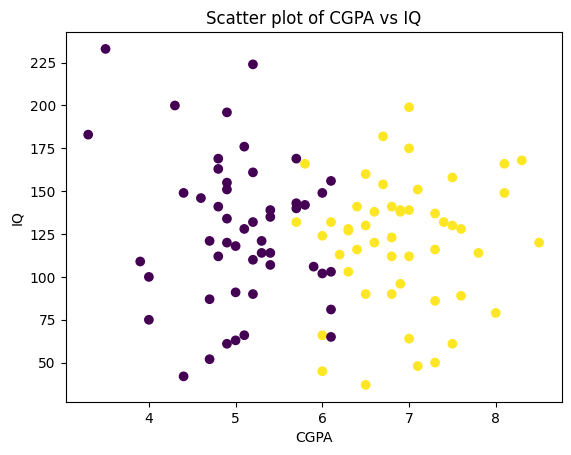

In [8]:
plt.scatter(df['cgpa'], df['iq'],c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Scatter plot of CGPA vs IQ')
plt.show()

# Yellow data points shows placement done and blue data points shows placement not done. 

# Selecting columns for model training


In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [11]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [12]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

Train test split

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.1)

In [14]:
X_train

,cgpa,iq
12,5.4,139.0
92,5.2,110.0
87,5.7,132.0
58,8.0,79.0
28,5.2,90.0
...,...,...
36,5.7,140.0
81,5.4,107.0
47,5.2,161.0
59,4.8,112.0


In [15]:
Y_train

12    0
92    0
87    1
58    1
28    0
     ..
36    0
81    0
47    0
59    0
73    0
Name: placement, Length: 90, dtype: int64

In [16]:
# Scaling values from -1 to 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [17]:
X_train

array([[-0.56980908,  0.4509732 ],
       [-0.74849486, -0.28930356],
       [-0.30178042,  0.2722857 ],
       [ 1.75310599, -1.08063388],
       [-0.74849486, -0.79983925],
       [ 0.32361979,  0.50202676],
       [ 1.30639155, -1.54011601],
       [-0.30178042,  1.21677673],
       [ 0.41296268, -2.15275884],
       [ 1.30639155,  0.22123213],
       [-2.44600972,  1.57415172],
       [-0.03375176, -0.49351784],
       [-1.8206095 , -0.54457141],
       [-0.21243753,  0.52755355],
       [ 0.2342769 ,  0.14465178],
       [-0.83783774,  0.17017856],
       [ 1.30639155,  0.9359821 ],
       [ 1.39573444, -0.82536604],
       [ 1.12770578, -0.13614285],
       [-0.03375176, -1.94854456],
       [ 0.2342769 ,  0.17017856],
       [-1.8206095 , -1.18274102],
       [ 0.59164845,  0.83387496],
       [ 0.2342769 , -0.46799105],
       [-1.90995239, -0.31483034],
       [ 0.85967712,  1.36993744],
       [-1.19520929, -1.76985707],
       [ 1.12770578,  0.39991963],
       [-1.10586641,

In [18]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.50230557,  0.42544641],
       [-0.56980908,  0.34886606],
       [-1.01652352,  0.75729461],
       [ 0.41296268,  0.22123213],
       [ 1.39573444,  0.17017856],
       [-1.10586641,  1.21677673],
       [-1.46323795,  0.70624104],
       [ 0.77033423,  0.4509732 ],
       [-2.26732394,  2.85049095],
       [-0.83783774, -1.41248208]])

TRraining the mode : Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
clf = LogisticRegression()

In [27]:
clf.fit(X_train,Y_train)  

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
clf.predict(X_test)

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [21]:
Y_test

48    1
49    0
89    0
57    1
30    1
75    0
88    0
60    1
50    0
9     0
Name: placement, dtype: int64

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_true=Y_test,y_pred=clf.predict(X_test))

1.0

In [32]:
y_pred= clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score